In [1]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error

# neural_network
from sklearn.neural_network import MLPClassifier,\
                                   MLPRegressor,\
                                   BernoulliRBM

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from keras import layers
from keras import regularizers
from keras import initializers



from keras.models import Sequential
from keras.models import Model
# layers
from keras.layers import Input
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Normalization,BatchNormalization
#CNN
from keras.layers import Conv2D
from keras.layers import MaxPooling2D,AveragePooling2D
#activations
from keras.activations import sigmoid
#utils
from keras.utils import to_categorical

#callbacks
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.callbacks import TensorBoard
from keras.callbacks import LambdaCallback
from keras.callbacks import TerminateOnNaN
from keras.callbacks import CSVLogger
from keras.callbacks import LearningRateScheduler
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import Callback

#preprocessing
from keras.preprocessing import image


import sys
from copy import deepcopy

import kagglehub


In [3]:
early_stop_val_loss = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
early_stop_val_acu = EarlyStopping(
    monitor='val_Accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True
)

#### Get Fashion Mnist dataset


In [4]:
from keras.datasets import mnist
# 1. Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Preprocess data
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (60000, 28, 28, 1), y_train shape: (60000, 10)
X_test shape: (10000, 28, 28, 1), y_test shape: (10000, 10)


#### Create sequential Models based on neural network

In [9]:
tf.random.set_seed(42)
model_no_normalizations_nn = keras.Sequential()
model_no_normalizations_nn.add(keras.layers.InputLayer(shape=(28,28,1)))
model_no_normalizations_nn.add(keras.layers.Flatten())
model_no_normalizations_nn.add(keras.layers.Dense(units = 300,name = 'Layer300',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
model_no_normalizations_nn.add(keras.layers.Dense(units = 150,name = 'Layer150',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
model_no_normalizations_nn.add(keras.layers.Dense(units = 10,name = 'OutPut10',activation="softmax",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))

In [10]:
model_no_normalizations_nn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer300 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer150 (Dense)                │ (None, 150)            │        45,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutPut10 (Dense)                │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,160 (1.08 MB)

 Trainable params: 282,160 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
run_eagerly_status = True
model_no_normalizations_nn.compile(
    optimizer = 'Adam',
    # ================ Loss & Loss weight ==========================================
    loss         = 'CategoricalCrossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['Accuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)

In [13]:
batch_size_  = 64
epochs_      = 30
sample_size_ = X_train.shape[0]
Validation_sample_set = X_test.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_no_normalizations_nn = model_no_normalizations_nn.fit(x = X_train, y = y_train, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test, y_test),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_,         
)

Step per epoch: 937
validation_steps: 156
Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 51ms/step - Accuracy: 0.8827 - loss: 0.4007 - val_Accuracy: 0.9677 - val_loss: 0.1062
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - Accuracy: 0.9705 - loss: 0.0957 - val_Accuracy: 0.9725 - val_loss: 0.0892
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - Accuracy: 0.9825 - loss: 0.0582 - val_Accuracy: 0.9723 - val_loss: 0.0904
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - Accuracy: 0.9882 - loss: 0.0390 - val_Accuracy: 0.9780 - val_loss: 0.0822
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - Accuracy: 0.9909 - loss: 0.0278 - val_Accuracy: 0.9773 - val_loss: 0.0842
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - Accuracy: 0.9932 - loss: 0.0222 - val_Accuracy: 0.9733 - val_loss: 0.0983
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - Accuracy: 0.9936 - loss: 0.0211 - val_Accuracy: 0.9763 - val_loss: 0.0831
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms

#### Models Accuracy and loss plot per epoch

History Columns name: Index(['Accuracy', 'loss', 'val_Accuracy', 'val_loss', 'epoch'], dtype='object')


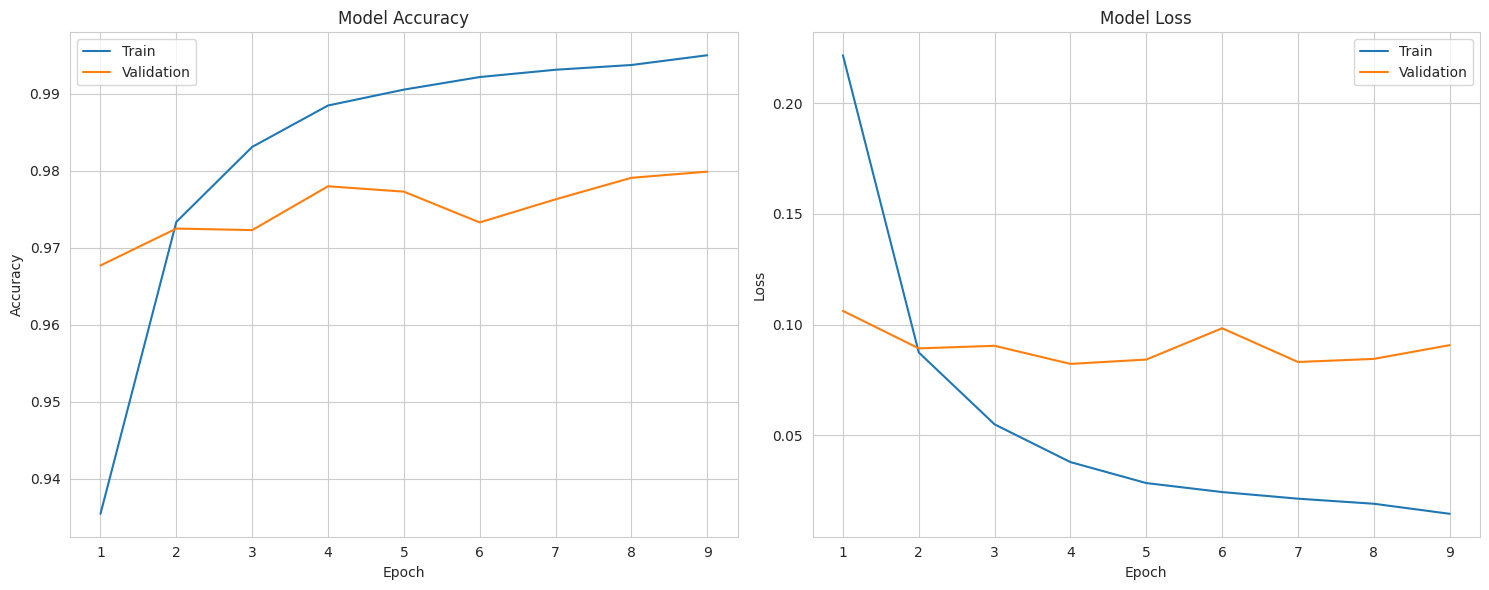

In [14]:
history_df = pd.DataFrame(history_no_normalizations_nn.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Model Accuracy
- Training Accuracy
  - Increases steadily from ~0.93 to ~0.99 across 9 epochs, shows the model is learning patterns in the training data effectively.
- Validation Accuracy
 - Fluctuates slightly but stays relatively stable around ~0.95–0.97.it doesn’t improve much after the first few epochs suggests the model’s ability to generalize is plateauing

hints at possible $overfitting$ — the model is memorizing training data rather than improving generalization.

#### Model Loss:
- Training Loss (blue line):
    - Decreases consistently from ~0.22 to ~0.02.
    - This is expected: as training progresses, the model makes fewer mistakes on training data.
- Validation Loss (orange line):
    - Fluctuates between ~0.05 and ~0.15 without a clear downward trend.
    - This instability suggests the model struggles to reduce errors on unseen data.

The ***divergence between training loss (falling) and validation loss (unstable) is another sign of $overfitting$***. The model is improving on training data but not on validation data



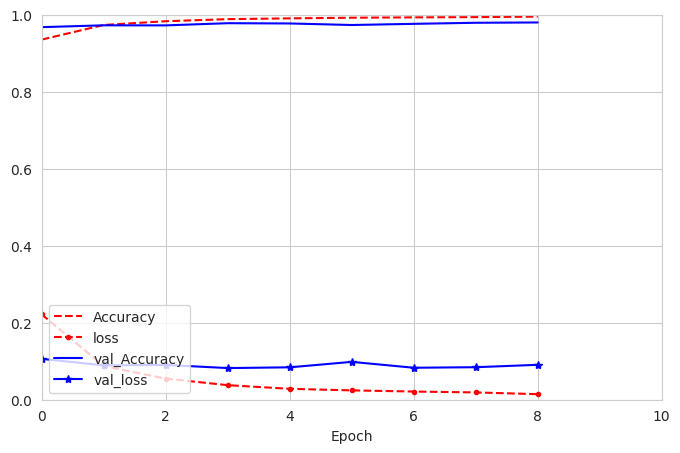

In [15]:
pd.DataFrame(history_no_normalizations_nn.history).plot(
    figsize=(8, 5), xlim=[0, 10], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code

plt.show()

In [16]:
loss, acc = model_no_normalizations_nn.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - Accuracy: 0.9738 - loss: 0.0969
Test Loss: 0.08220819383859634
Test Accuracy: 0.9779999852180481


#### Confusion Matrix Plot

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[[ 959    0    3    0    0    3    7    4    2    2]
 [   0 1119    3    1    0    0    2    6    4    0]
 [   2    0 1005    7    1    0    2   11    4    0]
 [   0    0    3  997    0    2    0    5    2    1]
 [   1    0    2    0  958    0    5    4    3    9]
 [   2    0    0    6    2  870    3    2    4    3]
 [   0    2    1    0    6   10  938    0    1    0]
 [   1    0    6    1    1    0    0 1013    3    3]
 [   0    0    5    2    3    4    2    4  951    3]
 [   1    2    1    7   10    3    1   10    4  970]]


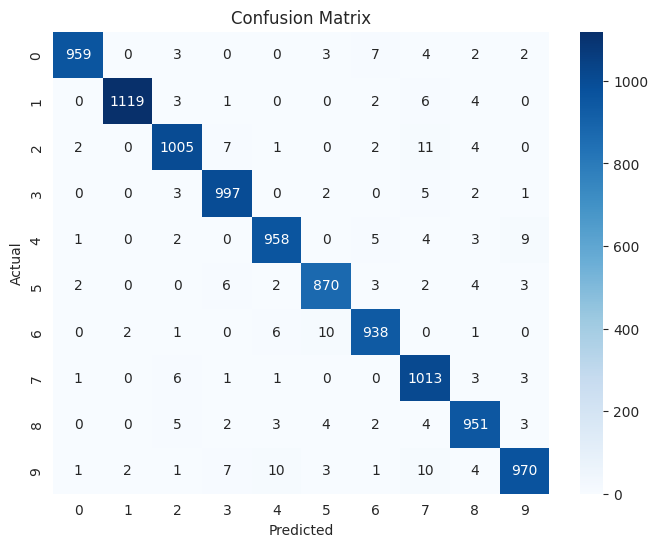

In [17]:
y_proba = model_no_normalizations_nn.predict(X_test)
y_pred = y_proba.argmax(axis=1)
y_true = y_test.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Correct Predictions (Confusion Matrix on Test Data set)
- Most values lie along the diagonal (e.g., class 1 has 1119 correct predictions, class 7 has 1013, class 9 has 970).
- This indicates the model is performing very well overall — the majority of samples are classified correctly

- Class 0: Misclassified as 2, 5, 6, 7, 8, 9 a few times (e.g., 7 times as class 6).
- Class 4: Misclassified as 9 nine times — this is the largest single error count in the matrix.
- Class 9: Misclassified as 4 ten times, and also as 7 ten times.
- Class 6: Misclassified as 5 ten times

- High accuracy overall: The diagonal dominance shows the classifier is strong.
    - Confusion between similar-looking digits (likely MNIST dataset):
    - 4 vs 9 → visually similar curves.
    - 6 vs 5 → overlapping shapes.
    - 9 vs 7 → similar top strokes.



In [5]:
#clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_normalizations_droput_nn = keras.Sequential()
model_normalizations_droput_nn.add(keras.layers.InputLayer(shape=(28,28,1)))
model_normalizations_droput_nn.add(keras.layers.Flatten())

model_normalizations_droput_nn.add(keras.layers.Dense(units = 128,name = 'Layer128',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
model_normalizations_droput_nn.add(BatchNormalization())
model_normalizations_droput_nn.add(Dropout(0.3))

model_normalizations_droput_nn.add(keras.layers.Dense(units = 150,name = 'Layer150',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
model_normalizations_droput_nn.add(BatchNormalization())
model_normalizations_droput_nn.add(Dropout(0.3))

model_normalizations_droput_nn.add(keras.layers.Dense(units = 10,name = 'OutPut10',activation="softmax",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))

In [6]:
model_normalizations_droput_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer128 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer150 (Dense)                │ (None, 150)            │        19,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutPut10 (Dense)                │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,452 (478.33 KB)

 Trainable params: 121,896 (476.16 KB)

 Non-trainable params: 556 (2.17 KB)

In [7]:
run_eagerly_status = True
model_normalizations_droput_nn.compile(
    optimizer = 'Adam',
    # ================ Loss & Loss weight ==========================================
    loss         = 'CategoricalCrossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['Accuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)

In [8]:
batch_size_  = 64
epochs_      = 30
sample_size_ = X_train.shape[0]
Validation_sample_set = X_test.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_normalizations_droput_nn = model_normalizations_droput_nn.fit(x = X_train, y = y_train, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test, y_test),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_,         
)

Step per epoch: 937
validation_steps: 156
Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 89s 91ms/step - Accuracy: 0.8120 - loss: 0.6091 - val_Accuracy: 0.9584 - val_loss: 0.1374
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 91ms/step - Accuracy: 0.9360 - loss: 0.2099 - val_Accuracy: 0.9662 - val_loss: 0.1054
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 91ms/step - Accuracy: 0.9496 - loss: 0.1615 - val_Accuracy: 0.9721 - val_loss: 0.0913
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 91ms/step - Accuracy: 0.9570 - loss: 0.1377 - val_Accuracy: 0.9719 - val_loss: 0.0883
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 91ms/step - Accuracy: 0.9628 - loss: 0.1207 - val_Accuracy: 0.9734 - val_loss: 0.0822
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - Accuracy: 0.9652 - loss: 0.1099 - val_Accuracy: 0.9764 - val_loss: 0.0727
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - Accuracy: 0.9674 - loss: 0.1026 - val_Accuracy: 0.9753 - val_loss: 0.0749
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 87s 93ms

History Columns name: Index(['Accuracy', 'loss', 'val_Accuracy', 'val_loss', 'epoch'], dtype='object')


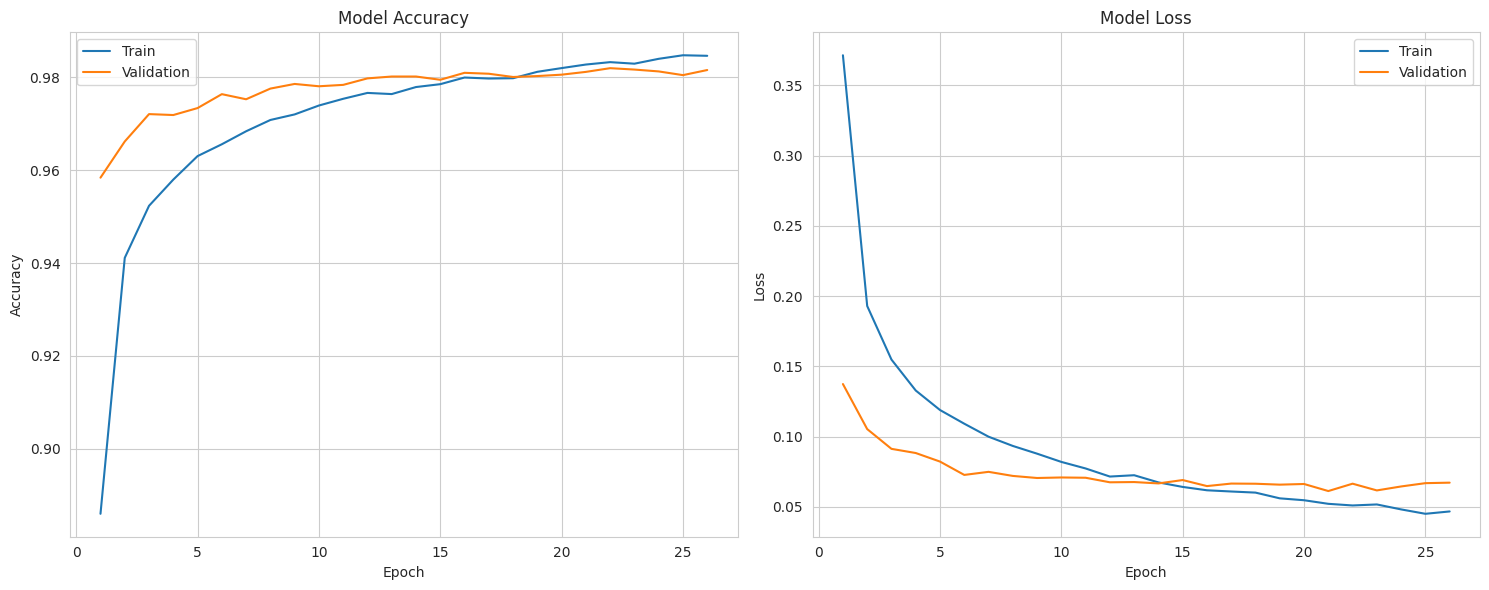

In [9]:
history_df = pd.DataFrame(history_normalizations_droput_nn.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Model Accuracy (minimal overfitting): 

- Blue line (Training Accuracy): Shows how well the model performs on the training data. It steadily increases from ~0.89 to ~0.99, meaning the model is learning patterns in the training set effectively.
- Orange line (Validation Accuracy): Tracks performance on unseen validation data. It also rises over time, ending close to the training accuracy but slightly lower.
- Interpretation: Both curves improve together, which is a good sign. The small gap between training and validation accuracy suggests the model generalizes well, with only minimal overfitting.

#### Model Loss (good generalization):

- Blue line (Training Loss): Starts higher and decreases consistently, reaching close to 0 by the final epochs. Lower loss means fewer errors in predictions.
- Orange line (Validation Loss): Also decreases, though it stays slightly above the training loss.
- Interpretation: The downward trend shows the model is reducing errors over time. The gap between training and validation loss is small, again suggesting good generalization.

- *Learning is effective*: Accuracy improves and loss decreases across epochs.
- *Generalization looks solid*: Validation metrics track closely with training metrics, meaning the model isn’t just memorizing the training data.
- *Minimal overfitting*: The slight gap between training and validation curves is expected; it shows the model is learning but not excessively biased toward the training set.

**So we can see batch normalizations and dropout working fine in this models. And overfitting in reduced.** 


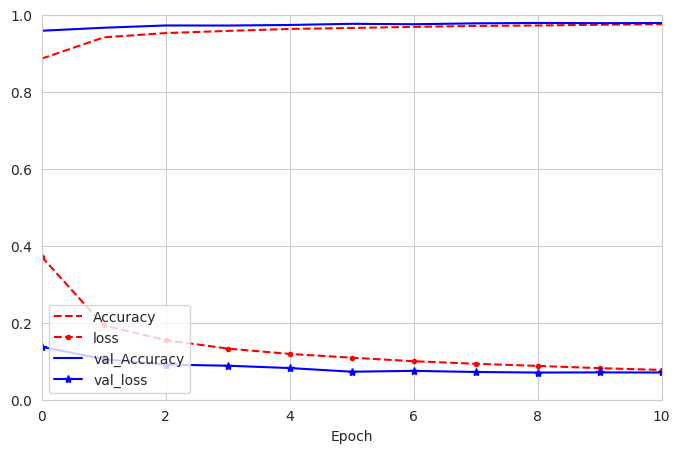

In [10]:
pd.DataFrame(history_normalizations_droput_nn.history).plot(
    figsize=(8, 5), xlim=[0, 10], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code

plt.show()

In [11]:
loss, acc = model_normalizations_droput_nn.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - Accuracy: 0.9784 - loss: 0.0694
Test Loss: 0.06127190589904785
Test Accuracy: 0.9811999797821045


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
[[ 973    0    0    1    1    0    1    1    2    1]
 [   0 1119    3    3    0    1    2    1    6    0]
 [   2    2 1008    4    2    0    2    7    4    1]
 [   0    0    0 1000    0    2    0    4    2    2]
 [   0    0    0    0  967    0    3    1    1   10]
 [   2    0    0    9    1  871    3    0    4    2]
 [   2    2    0    1    5    3  942    0    3    0]
 [   2    2    9    5    2    0    0 1002    0    6]
 [   2    0    3    6    4    3    1    4  949    2]
 [   1    2    1    7    6    3    1    3    4  981]]


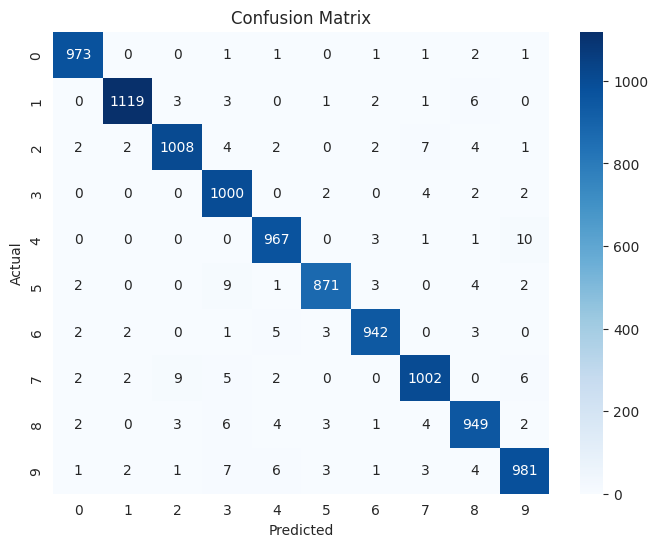

In [12]:
y_proba = model_normalizations_droput_nn.predict(X_test)
y_pred = y_proba.argmax(axis=1)
y_true = y_test.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### What a Confusion Matrix Represents:

- **Strong diagonal dominance:** Most values are concentrated along the diagonal (e.g., class 1 has 1119 correct predictions, class 7 has 1002, etc.). This means the model is highly accurate.

- **Few misclassifications:** Off-diagonal values are small compared to diagonal ones:

    - Class 0: 973 correct, only a handful misclassified (like 2 predicted as class 7).
    - Class 5: 871 correct, with some confusion toward class 3 (9 misclassified).
    - Class 9: 981 correct, but a few misclassified as class 3 (7 cases).
    - Most confusion occurs between visually similar digits:
    - Digits like 5 vs 3, 9 vs 4, and 8 vs 3 show small clusters of errors.
    - This is common in datasets like MNIST, where certain digits share similar shapes.

#### Performance Insights:

- **High accuracy overall**: With diagonal values consistently near 950–1100, the model is performing very well.
- **Error patterns are localized**: Misclassifications are not random; they cluster around digits that look alike.
- **Generalization looks strong:** The confusion matrix confirms what your accuracy/loss graphs suggested — the model is learning effectively with minimal overfitting

*Model is highly accurate across all classes, with only minor confusion between similar-looking digits*


In [15]:
#clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_normalizations_droput_cnn = keras.Sequential()
model_normalizations_droput_cnn.add(keras.layers.InputLayer(shape=(28,28,1)))
model_normalizations_droput_cnn.add(Conv2D(filters=32,kernel_size=7,strides = 1,padding ="same",
                                       data_format= "channels_last", 
                                       activation='relu',use_bias=  True,
                                       kernel_initializer = "he_uniform", bias_initializer=  "zeros"))
model_normalizations_droput_cnn.add(BatchNormalization())
model_normalizations_droput_cnn.add(MaxPooling2D((2,2)))
model_normalizations_droput_cnn.add(Dropout(0.25))
#=====================================================
model_normalizations_droput_cnn.add(Conv2D(filters=64,kernel_size=3,strides = 1,padding ="same",
                                       data_format= "channels_last", 
                                       activation='relu',use_bias=  True,
                                       kernel_initializer = "he_uniform", bias_initializer=  "zeros"))
model_normalizations_droput_cnn.add(BatchNormalization())
model_normalizations_droput_cnn.add(MaxPooling2D((2,2)))
model_normalizations_droput_cnn.add(Dropout(0.25))
#=====================================================
model_normalizations_droput_cnn.add(Conv2D(filters=128,kernel_size=3,strides = 1,padding ="same",
                                       data_format= "channels_last", 
                                       activation='relu',use_bias=  True,
                                       kernel_initializer = "he_uniform", bias_initializer=  "zeros"))
model_normalizations_droput_cnn.add(BatchNormalization())
model_normalizations_droput_cnn.add(MaxPooling2D((2,2)))
model_normalizations_droput_cnn.add(Dropout(0.25))
#======================================================
model_normalizations_droput_cnn.add(Flatten())
model_normalizations_droput_cnn.add(keras.layers.Dense(units = 128,name = 'Layer128',activation="relu",
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
model_normalizations_droput_cnn.add(BatchNormalization())
model_normalizations_droput_cnn.add(Dropout(0.5))
#======================================================
model_normalizations_droput_cnn.add(keras.layers.Dense(units = 64,name = 'Layer64',activation="relu",
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
model_normalizations_droput_cnn.add(BatchNormalization())
model_normalizations_droput_cnn.add(Dropout(0.5))
#=====================================================
model_normalizations_droput_cnn.add(keras.layers.Dense(units = 10,name = 'OutLayer10',activation="softmax",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))

In [16]:
model_normalizations_droput_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer128 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer64 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutLayer10 (Dense)              │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,106 (984.79 KB)

 Trainable params: 251,274 (981.54 KB)

 Non-trainable params: 832 (3.25 KB)

In [17]:
run_eagerly_status = True
model_normalizations_droput_cnn.compile(
    optimizer = 'Adam',
    # ================ Loss & Loss weight ==========================================
    loss         = 'CategoricalCrossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['Accuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)

In [18]:
batch_size_  = 128
epochs_      = 30
sample_size_ = X_train.shape[0]
Validation_sample_set = X_test.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_normalizations_droput_val_loss_cnn = model_normalizations_droput_cnn.fit(x = X_train, y = y_train, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test, y_test),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_  ,                 
)

Step per epoch: 468
validation_steps: 78
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 189ms/step - Accuracy: 0.6174 - loss: 1.2430 - val_Accuracy: 0.9499 - val_loss: 0.1645
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 188ms/step - Accuracy: 0.9458 - loss: 0.1912 - val_Accuracy: 0.9823 - val_loss: 0.0535
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 189ms/step - Accuracy: 0.9662 - loss: 0.1215 - val_Accuracy: 0.9856 - val_loss: 0.0418
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 189ms/step - Accuracy: 0.9736 - loss: 0.0941 - val_Accuracy: 0.9872 - val_loss: 0.0363
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 188ms/step - Accuracy: 0.9778 - loss: 0.0790 - val_Accuracy: 0.9909 - val_loss: 0.0259
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 187ms/step - Accuracy: 0.9812 - loss: 0.0692 - val_Accuracy: 0.9905 - val_loss: 0.0275
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 189ms/step - Accuracy: 0.9831 - loss: 0.0583 - val_Accuracy: 0.9916 - val_loss: 0.0258
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 88

History Columns name: Index(['Accuracy', 'loss', 'val_Accuracy', 'val_loss', 'epoch'], dtype='object')


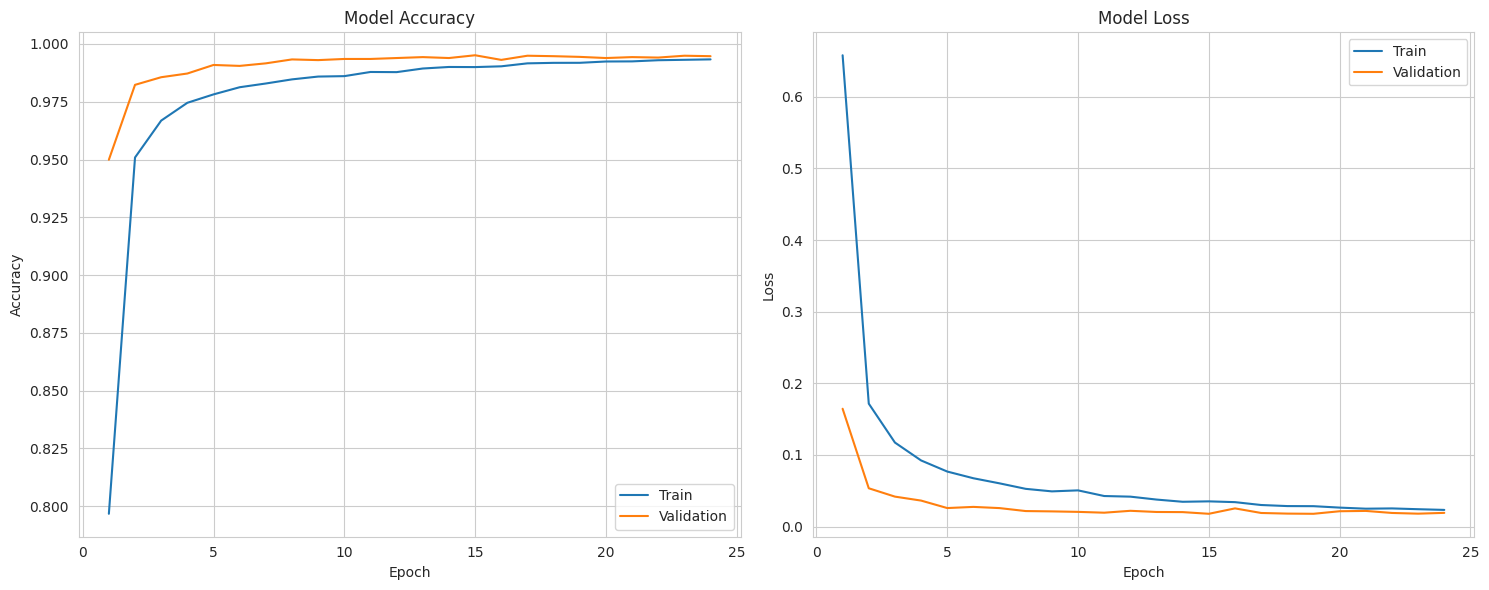

In [19]:
history_df = pd.DataFrame(history_normalizations_droput_val_loss_cnn.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Model Accuracy :

- Blue line (Training Accuracy): Starts lower and steadily increases, reaching close to 1.0 by the final epochs.
- Orange line (Validation Accuracy): Also rises, and interestingly, it stays slightly higher than training accuracy for most epochs.

#### Interpretation:
- Normally, *training accuracy is equal to or higher than validation accuracy*.
- Here, *validation accuracy being higher suggests that the model generalizes very well* — it’s not just memorizing training data, but actually performing better on unseen data.
- This can happen if regularization techniques (like dropout, weight decay, or data augmentation) make the training task harder, while validation benefits from those learned general patterns.

#### Model Loss (minimal overfitting):
- Blue line (Training Loss): Decreases steadily, showing the model is reducing errors on training data.
- Orange line (Validation Loss): Also decreases, staying close to training loss but slightly higher.
- Interpretation:
- Both curves trending downward means the *model is learning effectively*.
- The small gap between training and validation loss indicates *minimal overfitting*

    - **Strong generalization**: Validation accuracy consistently higher than training accuracy is unusual but positive — it means the model is robust.
    - **Healthy learning curves**: Accuracy improves and loss decreases smoothly, with no sudden divergence.
    - **Minimal overfitting**: Training and validation metrics track closely together, showing balance.


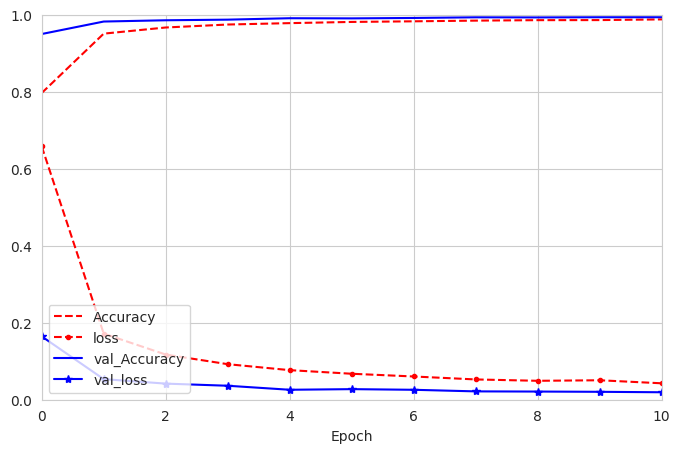

In [20]:
pd.DataFrame(history_normalizations_droput_val_loss_cnn.history).plot(
    figsize=(8, 5), xlim=[0, 10], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code

plt.show()

In [21]:
loss, acc = model_normalizations_droput_cnn.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - Accuracy: 0.9935 - loss: 0.0217
Test Loss: 0.01785191521048546
Test Accuracy: 0.9944000244140625


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
[[ 977    0    0    0    0    0    2    1    0    0]
 [   0 1133    1    0    0    0    1    0    0    0]
 [   0    1 1028    0    0    0    0    2    1    0]
 [   0    0    0 1005    0    3    0    0    0    2]
 [   0    0    0    0  981    0    0    0    0    1]
 [   1    0    0    4    0  885    1    0    0    1]
 [   2    1    0    0    3    1  951    0    0    0]
 [   0    2    2    1    0    0    0 1021    0    2]
 [   1    0    1    1    0    1    0    1  968    1]
 [   0    0    0    0    6    4    0    1    3  995]]


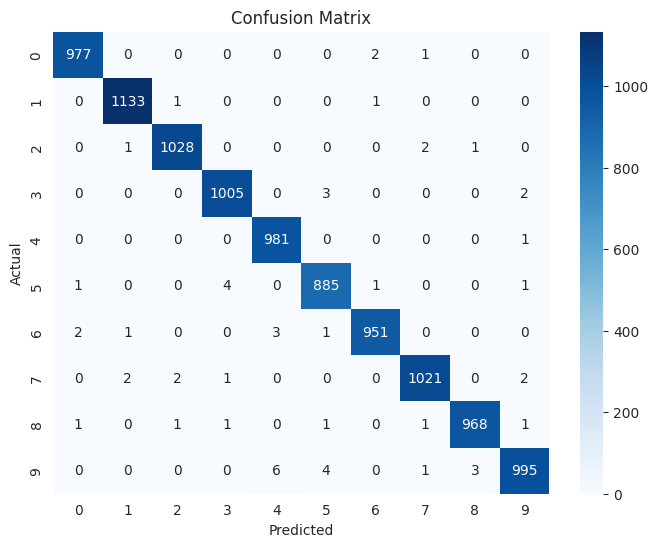

In [22]:
y_proba = model_normalizations_droput_cnn.predict(X_test)
y_pred = y_proba.argmax(axis=1)
y_true = y_test.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- **Strong diagonal dominance**: Most values are concentrated along the diagonal (e.g., class 1 has 1133 correct, class 7 has 1021 correct, class 9 has 995 correct). This means the model is highly accurate.
- **Minimal misclassifications**: Off-diagonal values are very small compared to diagonal ones. For example:

    - Class 5: 885 correct, but 4 misclassified as class 3.
    - Class 9: 995 correct, but 6 misclassified as class 4 and 4 as class 5.
    - Class 8: 968 correct, with tiny confusion across neighboring digits.
    - Digits with near-perfect recognition: Classes like 1, 4, and 7 show almost flawless predictions (precision and recall ~0.99+).

-**Overall accuracy is extremely high** — nearly all digits are classified correctly.
- **Error patterns are localized** — confusion happens only between digits that look visually similar (e.g., 5 vs 3, 9 vs 4, 8 vs 3).
- **Balanced generalization** — no single class is disproportionately misclassified, which means the model is fair across all digits.



#### LeNet-5 architecture

Diagram‑Style Architecture (Sequential Flow):

Input (28x28x1 grayscale image)

   ↓

Conv2D (32 filters, 3x3, ReLU, SAME padding)

   ↓

MaxPooling2D (2x2)

   ↓

Conv2D (64 filters, 3x3, ReLU, SAME padding)

   ↓

MaxPooling2D (2x2)

   ↓

Conv2D (128 filters, 3x3, ReLU, SAME padding)

   ↓

Flatten

   ↓

Dense (128 units, ReLU)

   ↓

Dropout (0.5)

   ↓
   
Dense (10 units, Softmax → class probabilities)


#### LeNet-5 architecture with early stop based on val loss

In [32]:
#clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [33]:
from keras.datasets import fashion_mnist
# 1. Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 2. Preprocess data
# LeNet-5 expects 32x32 input, so we pad 28x28 to 32x32
X_train = tf.cast(tf.pad(tf.expand_dims(X_train, -1), [[0,0],[2,2],[2,2],[0,0]]), tf.float32) / 255.0
X_test = tf.cast(tf.pad(tf.expand_dims(X_test, -1), [[0,0],[2,2],[2,2],[0,0]]), tf.float32) / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [34]:


model_LeNet_cnn = keras.Sequential()
model_LeNet_cnn.add(keras.layers.InputLayer(shape=(32,32,1)))
model_LeNet_cnn.add(Conv2D(filters=6, kernel_size=(5,5),strides = (1, 1),padding ="valid",data_format = "channels_last",
    activation='tanh', kernel_initializer="glorot_uniform"))

# S2: Average Pooling (2x2, stride 2, tanh)
model_LeNet_cnn.add(AveragePooling2D(pool_size=(2,2), strides=2,padding="valid"))

# C3: Convolution (16 maps, 5x5 kernel, tanh)
model_LeNet_cnn.add(Conv2D(filters=16, kernel_size=(5,5),strides = (1, 1),padding ="valid",
activation='tanh',kernel_initializer="glorot_uniform"))

# S4: Average Pooling (2x2, stride 2, tanh)
model_LeNet_cnn.add(AveragePooling2D(pool_size=(2,2), strides=2))

# C5: Convolution (120 maps, 5x5 kernel, tanh)
model_LeNet_cnn.add(Conv2D(filters=120, kernel_size=(5,5), strides = (1, 1),padding ="valid",
activation='tanh',kernel_initializer="glorot_uniform"))

# Flatten
model_LeNet_cnn.add(Flatten())

# F6: Fully connected (84 units, tanh)
model_LeNet_cnn.add(Dense(units =84, activation='tanh',use_bias = True,kernel_initializer="glorot_uniform",
bias_initializer=initializers.Zeros()))

# Output: Fully connected (10 units, softmax)
model_LeNet_cnn.add(Dense(units = 10, activation='softmax',use_bias = True,kernel_initializer="glorot_uniform",
bias_initializer=initializers.Zeros()))

In [35]:
print(model_LeNet_cnn.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

None


In [36]:
# 4. Compile model_Lenet_acu
run_eagerly_status = True
model_LeNet_cnn.compile(
    optimizer = 'Adam',
    # ================ Loss & Loss weight ==========================================
    loss         = 'CategoricalCrossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['Accuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)

In [37]:
batch_size_  = 128
epochs_      = 40
sample_size_ = X_train.shape[0]
Validation_sample_set = X_test.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_LeNet_val_loss_cnn = model_LeNet_cnn.fit(x = X_train, y = y_train, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test, y_test),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_  ,                 
)

Step per epoch: 468
validation_steps: 78
Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - Accuracy: 0.6962 - loss: 0.8514 - val_Accuracy: 0.8133 - val_loss: 0.4888
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - Accuracy: 0.8427 - loss: 0.4344 - val_Accuracy: 0.8458 - val_loss: 0.4229
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - Accuracy: 0.8624 - loss: 0.3798 - val_Accuracy: 0.8590 - val_loss: 0.3854
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 78ms/step - Accuracy: 0.8726 - loss: 0.3485 - val_Accuracy: 0.8648 - val_loss: 0.3667
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - Accuracy: 0.8816 - loss: 0.3258 - val_Accuracy: 0.8683 - val_loss: 0.3552
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - Accuracy: 0.8874 - loss: 0.3074 - val_Accuracy: 0.8725 - val_loss: 0.3467
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - Accuracy: 0.8926 - loss: 0.2919 - val_Accuracy: 0.8752 - val_loss: 0.3393
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/

In [38]:
loss, acc = model_LeNet_cnn.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - Accuracy: 0.8816 - loss: 0.3185
Test Loss: 0.3136228024959564
Test Accuracy: 0.8837000131607056


History Columns name: Index(['Accuracy', 'loss', 'val_Accuracy', 'val_loss', 'epoch'], dtype='object')


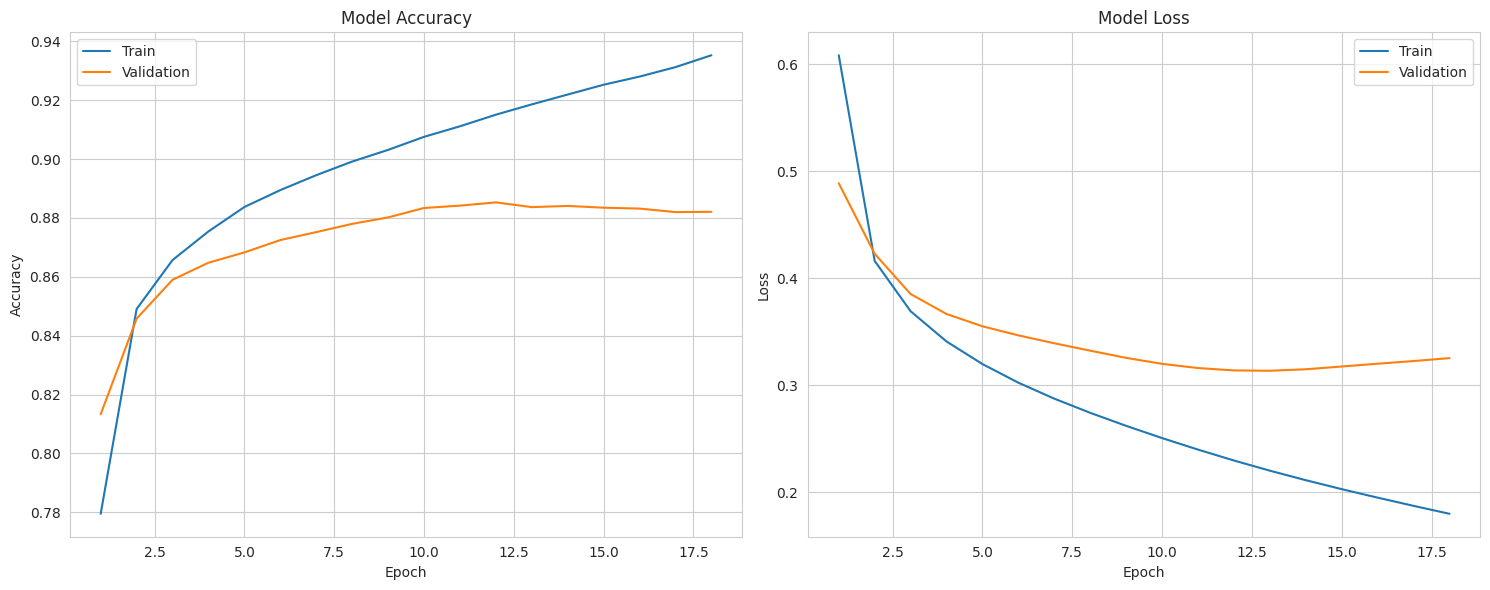

In [39]:
history_df = pd.DataFrame(history_LeNet_val_loss_cnn.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Model Accuracy:
- Training Accuracy (blue): Increases steadily from ~0.78 to ~0.94, showing the model is learning patterns in the training data.
- Validation Accuracy (orange): Improves initially, then plateaus around epoch 10 at ~0.90.
- Interpretation:
- The model learns well at first, but after ~10 epochs, validation accuracy stops improving while training accuracy continues to rise.
- This gap suggests the model is starting to overfit — it’s memorizing training data more than generalizing to unseen data.

#### Model Loss:
- Training Loss (blue): Decreases consistently, showing fewer errors on training data.
- Validation Loss (orange): Drops initially but then starts increasing after epoch 12.
- Interpretation:
- Rising validation loss while training loss keeps falling is a classic sign of overfitting.
- The model is fitting training data too tightly, which hurts performance on validation data.

- **Early learning is effective**: Both accuracy and loss improve in the **first 10–12 epochs**.
- **Overfitting emerges later**: Validation accuracy plateaus and validation loss rises, while training metrics keep improving.
- **Best stopping point**: Around epoch 10–12, before overfitting sets in, the model achieves its best balance between training and validation performance.


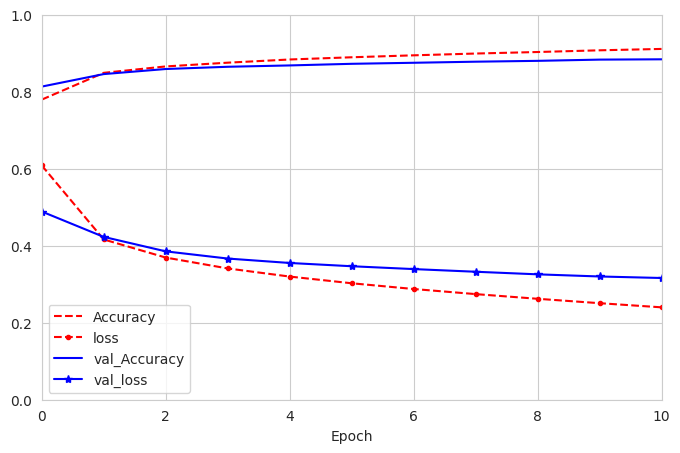

In [40]:
pd.DataFrame(history_LeNet_val_loss_cnn.history).plot(
    figsize=(8, 5), xlim=[0, 10], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
[[771   3  17  22   7   2 172   0   6   0]
 [  0 973   2  15   4   0   5   0   1   0]
 [ 12   0 844  15  62   0  67   0   0   0]
 [  9   9  10 897  39   0  31   0   5   0]
 [  1   1 123  25 791   0  59   0   0   0]
 [  0   0   0   1   0 964   0  24   2   9]
 [ 81   2  91  26  73   0 724   0   3   0]
 [  0   0   0   0   0  11   0 979   0  10]
 [  6   0  11   6   4   3   6   4 960   0]
 [  0   0   0   0   0  11   0  55   0 934]]


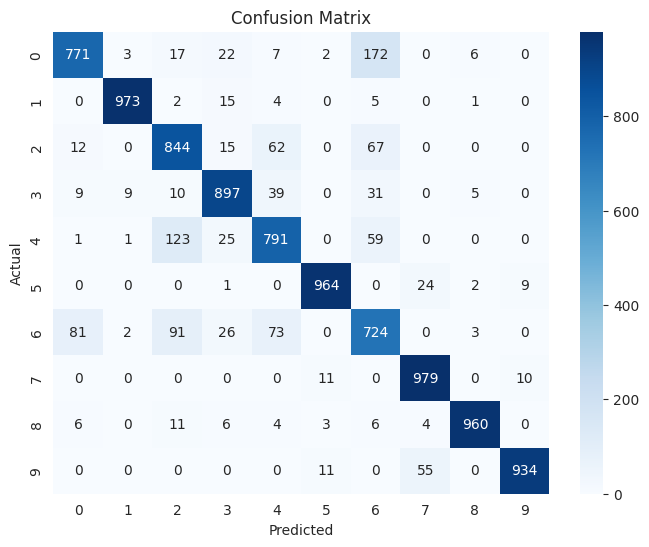

In [41]:
y_proba = model_LeNet_cnn.predict(X_test)
y_pred = y_proba.argmax(axis=1)
y_true = y_test.argmax(axis=1) # Corrected: Convert one-hot encoded y_test to integer labels
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Overall summary 

#### Models 1 - Neural Network (No Normalizations)
- Accuracy: Training accuracy rises quickly, but validation accuracy plateaus early.
- Loss: Training loss decreases steadily, while validation loss stays relatively flat.
- Interpretation:
- The model learns the training data well but struggles to generalize.
- Lack of normalization means internal covariate shift slows convergence and causes weaker validation performance.
- Signs of overfitting appear since validation doesn’t improve much

#### Models 2 - Neural Network (Batch Normalization + Dropout)
- Accuracy: Both training and validation accuracy steadily increase and converge closely.
- Loss: Both training and validation loss decrease together.
- Interpretation:
- Batch normalization stabilizes training by reducing internal covariate shift.
- Dropout prevents overfitting by forcing the network to learn more robust features.
- This setup shows balanced generalization — validation tracks training closely.

#### Models 3 - CNN (Batch Normalization + Dropout + Max Pooling)
- Accuracy: Training and validation accuracy both climb near 1.0, converging tightly.
- Loss: Both losses drop significantly, with validation loss closely following training loss.
- Interpretation:
- Convolutional layers capture spatial features better than dense-only networks.
- Max pooling reduces dimensionality and improves invariance to shifts/distortions.
- Combined with normalization and dropout, this architecture achieves the best performance and generalization among the four.

#### Models 4 - LeNet-5 Architecture
- Accuracy: Training accuracy improves steadily, but validation accuracy plateaus lower (~0.94).
- Loss: Training loss decreases, validation loss decreases only slightly.
- Interpretation:
- LeNet-5 is a classic CNN, but relatively shallow compared to modern architectures.
- It performs well but doesn’t reach the same level of generalization as deeper CNNs with normalization and dropout.
- Shows moderate overfitting — validation lags behind training



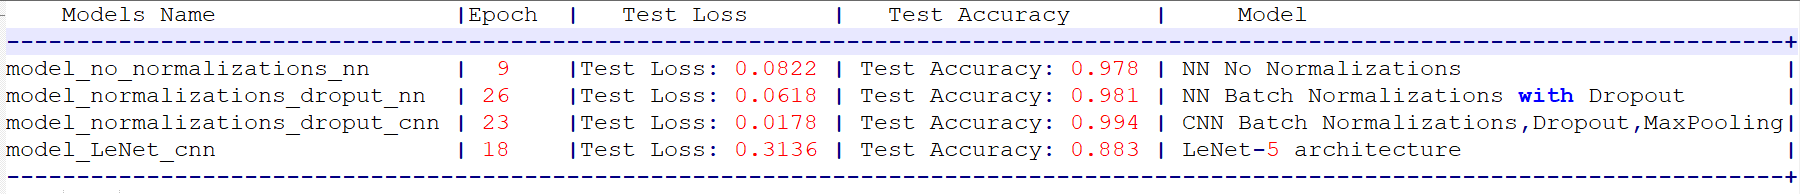

#### 1. NN No Normalizations
- Accuracy: 97.8% — strong, but not the best.
- Loss: 0.0822 — relatively low, but higher than more advanced setups.
- Takeaway: Performs decently, but without normalization, convergence is less stable and generalization weaker.

#### 2. NN with Batch Normalization + Dropout
- Accuracy: 98.1% — slightly better than the plain NN.
- Loss: 0.0618 — lower, showing improved error reduction.
- Takeaway: BatchNorm stabilizes training, Dropout reduces overfitting → better generalization.

#### 3. CNN with Batch Normalization + Dropout + MaxPooling
- Accuracy: 99.4% — the best among all models.
- Loss: 0.0178 — extremely low, meaning very few errors.
- Takeaway: Convolutional layers + pooling capture spatial features, while normalization and dropout ensure robustness. This is the most effective architecture here.

##### 4. LeNet-5
- Accuracy: 88.3% — significantly lower than the others.
- Loss: 0.3136 — much higher, indicating weaker performance.
- Takeaway: While historically important, LeNet-5 is shallow and less powerful compared to modern CNNs. It underfits relative to the other models
